In [1]:
# Download github repository
!git clone https://github.com/uw-cmg/RPV_model_benchmarking

Cloning into 'RPV_model_benchmarking'...
remote: Enumerating objects: 667, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 667 (delta 1), reused 0 (delta 0), pack-reused 656 (from 3)
Receiving objects: 100% (667/667), 1.31 GiB | 29.65 MiB/s, done.
Resolving deltas: 100% (125/125), done.
Updating files: 100% (623/623), done.


In [2]:
!pip install -r RPV_model_benchmarking/requirements.txt

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.4/883.4 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.2/82.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.9/111.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/

In [ ]:
# Restart the session (Runtime -> Restart Session) so the new installs can take effect

In [3]:
# Package imports
import pandas as pd
import numpy as np
from RPV_model_benchmarking.models import *
from RPV_model_benchmarking.data import *
from RPV_model_benchmarking.metrics import *
from RPV_model_benchmarking.plots import *

In [11]:
# Enter composition and irradiation feature values and use Jacobs26 model to
# make predictions

## User update desired conditions. T in degC, comp in wt%, flux in n/cm2-s, fluence in n/cm2
T = 290
Cu = 0.12
Ni = 0.69
Mn = 1.4
Si = 0.22
P = 0.009
C = 0.14
flux = 3*10**10
fluence = 10**20
##


d = {'temperature_C': T,
     'wt_percent_Cu': Cu,
     'wt_percent_Ni': Ni,
     'wt_percent_Mn': Mn,
     'wt_percent_P': P,
     'wt_percent_Si': Si,
     'wt_percent_C': C,
     'log(fluence_n_cm2)': np.log10(float(fluence)),
     'log(flux_n_cm2_sec)': np.log10(float(flux)),
     'fluence_n_cm2': fluence,
     'flux_n_cm2_sec': flux}

df = pd.DataFrame(d, index=[0])

preds, df = EnsembleNN_Jacobs26().predict(df, return_ebars=True)

df


model folder /content/RPV_model_benchmarking/model_files/Jacobs26/fullfit
Could not find designated model type in scikit-learn model library. Note the other supported modeltype is the keras.wrappers.scikit_learn.KerasRegressor model


,temperature_C,wt_percent_Cu,wt_percent_Ni,wt_percent_Mn,wt_percent_P,wt_percent_Si,wt_percent_C,log(fluence_n_cm2),log(flux_n_cm2_sec),fluence_n_cm2,flux_n_cm2_sec,Jacobs26 NN ensemble predicted TTS (degC),Jacobs26 NN ensemble error bars (degC)
0,290,0.12,0.69,1.4,0.009,0.22,0.14,20.0,10.477121,100000000000000000000,30000000000,106.493568,12.373808


In [2]:
# Make all the model predictions on the full dataset

df = DataLoader().load_rpv_data()

preds, df = EONY().predict(df)

preds, df = OWAY().predict(df)

preds, df = JOWAY().predict(df, atr2fte=1.38e20, nn_model='Jacobs26')

preds, df = E900().predict(df)

preds, df = GBR().predict(df)

preds, df = GKRR().predict(df)

preds, df = EnsembleNN_Jacobs23().predict(df, return_ebars=False)

preds, df = EnsembleNN_Jacobs26().predict(df, return_ebars=False)


joway df_nn (4535, 42)
model folder /content/RPV_model_benchmarking/model_files/Jacobs26/fullfit
Could not find designated model type in scikit-learn model library. Note the other supported modeltype is the keras.wrappers.scikit_learn.KerasRegressor model


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but BaggingRegressor was fitted without feature names
  warnings.warn(


142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


/content/RPV_model_benchmarking/models.py:892: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_features['Product Form_0'] = pf_0
/content/RPV_model_benchmarking/models.py:893: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_features['Product Form_1'] = pf_1
/content/RPV_model_benchmarking/models.py:894: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyd

Could not find designated model type in scikit-learn model library. Note the other supported modeltype is the keras.wrappers.scikit_learn.KerasRegressor model
 47/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but BaggingRegressor was fitted without feature names
  warnings.warn(


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
model folder /content/RPV_model_benchmarking/model_files/Jacobs26/fullfit
Could not find designated model type in scikit-learn model library. Note the other supported modeltype is the keras.wrappers.scikit_learn.KerasRegressor model
 49/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but BaggingRegressor was fitted without feature names
  warnings.warn(


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [3]:
df

,temperature_C,wt_percent_Cu,wt_percent_Ni,wt_percent_Mn,wt_percent_P,wt_percent_Si,wt_percent_C,log(fluence_n_cm2),log(flux_n_cm2_sec),Product Form,...,NN predicted TTS (degC) at 4e19 fluence,ATR2 CF TTS (degC) at 1.38e20 fluence,JOWAY predicted TTS (degC),E900 predicted TTS (degC),GBR predicted TTS (degC),GKRR predicted TTS (degC),Jacobs23 NN ensemble predicted TTS (degC),Jacobs23 NN ensemble error bars (degC),Jacobs26 NN ensemble predicted TTS (degC),Jacobs26 NN ensemble error bars (degC)
0,287.0,0.040,0.74,0.60,0.012,0.23,0.21,18.664548,11.165741,F,...,23.554607,98.125916,1.245163,8.703590,13.202558,21.216960,13.289200,NaN,13.042247,NaN
1,287.0,0.040,0.74,0.60,0.012,0.23,0.21,18.664548,11.165741,F,...,23.554607,98.125916,1.245163,8.703590,13.202558,21.216960,13.289200,NaN,13.042247,NaN
2,287.0,0.040,0.74,0.60,0.012,0.23,0.21,19.641970,11.160892,F,...,23.587172,98.125916,26.161501,31.357400,30.601126,25.355446,29.810862,NaN,25.365210,NaN
3,287.0,0.040,0.74,0.60,0.012,0.23,0.21,19.641970,11.160892,F,...,23.587172,98.125916,26.161501,31.357400,30.601126,25.355446,29.810862,NaN,25.365210,NaN
4,287.0,0.030,0.56,1.40,0.005,0.31,0.13,18.664548,11.165741,W,...,25.584995,93.229238,4.985810,8.433093,9.619796,4.015552,12.178897,NaN,11.005614,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4530,285.0,0.070,0.91,1.76,0.008,0.00,0.00,19.361728,12.812430,W,...,63.431293,135.291734,52.369315,37.977926,50.956894,58.982273,47.641254,NaN,49.474468,NaN
4531,285.0,0.070,0.91,1.76,0.008,0.00,0.00,19.591065,12.746066,W,...,63.579048,135.291734,62.918032,48.219231,64.827856,69.382052,62.907227,NaN,62.853558,NaN
4532,285.0,0.070,0.91,1.76,0.008,0.00,0.00,18.986772,11.835414,W,...,63.934174,135.291734,44.619628,26.629567,41.886790,51.638593,35.042156,NaN,34.244247,NaN
4533,291.0,0.067,0.69,0.00,0.009,0.00,0.00,19.193125,13.230449,F,...,27.253525,85.214497,14.631494,4.421055,1.999635,4.509019,14.734970,NaN,15.944262,NaN


In [4]:
# Just keep high fluence data and save the preds file

df = Metrics().filter_df(df, column_name='fluence_n_cm2', filter_val=6e19, filter_operation='greater')
df = Metrics().filter_df(df, column_name='datatype', filter_val='Plotter', filter_operation='equal')
df

,temperature_C,wt_percent_Cu,wt_percent_Ni,wt_percent_Mn,wt_percent_P,wt_percent_Si,wt_percent_C,log(fluence_n_cm2),log(flux_n_cm2_sec),Product Form,...,NN predicted TTS (degC) at 4e19 fluence,ATR2 CF TTS (degC) at 1.38e20 fluence,JOWAY predicted TTS (degC),E900 predicted TTS (degC),GBR predicted TTS (degC),GKRR predicted TTS (degC),Jacobs23 NN ensemble predicted TTS (degC),Jacobs23 NN ensemble error bars (degC),Jacobs26 NN ensemble predicted TTS (degC),Jacobs26 NN ensemble error bars (degC)
55,298.888889,0.100,0.180,1.42,0.016,0.25,0.300,20.029384,12.210868,P,...,34.150299,80.117692,64.793529,68.744293,89.739510,83.623600,75.749794,NaN,72.228836,NaN
181,262.000000,0.087,0.640,1.26,0.017,0.29,0.176,19.828660,11.240388,F,...,76.543480,156.259886,97.263288,100.948511,104.024582,104.900951,100.453285,NaN,106.873474,NaN
182,262.000000,0.087,0.640,1.26,0.017,0.29,0.176,20.053078,11.464807,F,...,75.042633,156.259886,133.999152,129.712560,147.618860,144.893409,131.221390,NaN,140.313538,NaN
183,262.918657,0.090,0.650,1.27,0.010,0.31,0.169,20.035029,11.361087,F,...,81.065407,150.043798,127.978373,116.748711,147.205189,145.612038,133.781479,NaN,141.442963,NaN
184,262.918657,0.090,0.650,1.27,0.010,0.31,0.169,20.064832,11.390890,F,...,80.800278,150.043798,133.548045,120.642986,146.256762,147.869161,137.684875,NaN,145.561844,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1821,292.777778,0.070,0.590,1.45,0.007,0.24,0.200,19.780317,10.858921,P,...,34.245472,101.057922,46.906123,47.136852,43.965144,48.674868,43.442955,NaN,44.074532,NaN
1822,292.777778,0.070,0.590,1.45,0.007,0.24,0.200,19.780317,10.858921,P,...,34.245472,101.057922,46.906123,47.136852,43.965144,48.674868,43.442955,NaN,44.074532,NaN
1823,292.777778,0.047,0.049,1.28,0.009,0.14,0.150,19.780317,10.858921,W,...,20.672901,60.365534,28.394836,35.596852,26.838923,19.497101,24.867025,NaN,25.592827,NaN
1895,287.000000,0.064,0.690,1.32,0.006,0.22,0.138,19.841985,11.299159,F,...,36.149422,108.765297,56.274565,48.540352,48.563905,51.950073,56.244244,NaN,54.503551,NaN


In [5]:
df.to_csv('RPV_preds_highfluence.csv', index=False)

(107, 52)
(89, 52)
(1, 89)


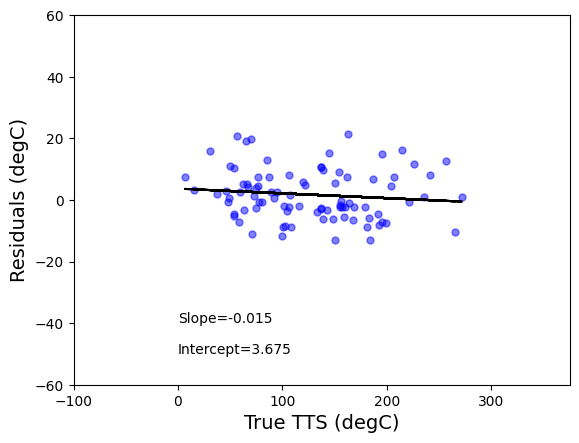

In [6]:
# Get model residuals and noise plot

print(df.shape)
df = Metrics().filter_df(df, column_name='Measured DT41J  [C]', filter_val=50, filter_operation='greater')
print(df.shape)

plot_residuals(trues=df['Measured DT41J  [C]'],
               preds=df['Jacobs26 NN ensemble predicted TTS (degC)'],
               name='Jacobs26')

plot_residuals(trues=df['Measured DT41J  [C]'],
               preds=df['Jacobs23 NN ensemble predicted TTS (degC)'],
               name='Jacobs23')

plot_model_noise(trues=df['Measured DT41J  [C]'], noise=9, num_points=df.shape[0])

In [7]:
# Get the 5fold CV benchmarking results

data = Benchmarking().get_5fold_benchmarks(model_name='Jacobs26', anchors='2026')
data

{'RMSE, all': np.float64(11.896322332987989),
 'RMSE, Plotter': np.float64(11.96468680061114),
 'RMSE, high fluence': np.float64(17.05358064793378),
 'RMSE, high fluence Plotter': np.float64(16.31665197303183),
 'RMSE, high TTS': np.float64(22.15765775558139),
 'RMSE, high TTS Plotter': np.float64(22.057493373510066),
 'RMSE, low Cu Plotter': np.float64(10.840479494490848),
 'RMSE, per alloy (average +/- stdev)': [np.float64(10.263153606599888),
  np.float64(6.228525501459469)]}

/content/RPV_model_benchmarking/plots.py:628: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_extra_plotter['residuals'] = res_plotter
/content/RPV_model_benchmarking/plots.py:629: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_extra_plotter['squared residuals'] = res_plotter ** 2
/content/RPV_model_benchmarking/plots.py:631: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

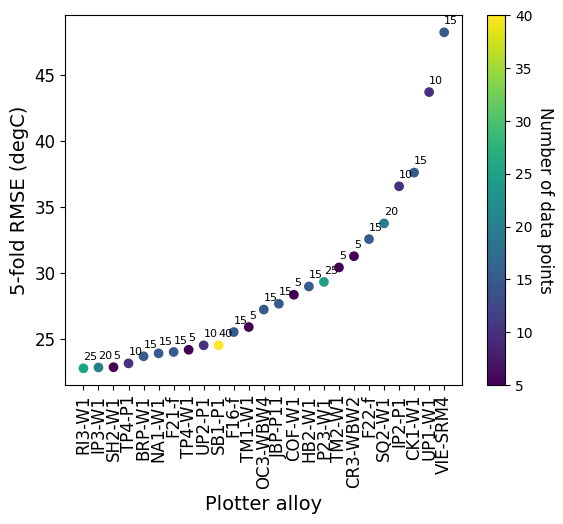

In [8]:
# Make best and worst alloy ranking plot

df_best, df_best_sort = plot_best_worst_alloys(model_name='Jacobs26', num_alloys=25, metric='RMSE', plot_type='best')

df_worst, df_worst_sort = plot_best_worst_alloys(model_name='Jacobs26', num_alloys=25, metric='RMSE', plot_type='worst')

In [9]:
# Make embrittlement curve

plot_embrittlement_curve(df,
                         model_name_list=['Jacobs23', 'Jacobs26'],
                         flux_list=[3*10**10, 3.68*10**12],
                         style='log',
                         num_points=50,
                         ymax=350,
                         xmin=16.5,
                         xmax=21.5,
                         anchors=[None, '2026'],
                         include_ATR2=True)

On alloy BRP-P1
Could not find designated model type in scikit-learn model library. Note the other supported modeltype is the keras.wrappers.scikit_learn.KerasRegressor model
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but BaggingRegressor was fitted without feature names
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Could not find designated model type in scikit-learn model library. Note the other supported modeltype is the keras.wrappers.scikit_learn.KerasRegressor model
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


/content/RPV_model_benchmarking/models.py:1380: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[k] = v


On alloy F43-F2
Could not find designated model type in scikit-learn model library. Note the other supported modeltype is the keras.wrappers.scikit_learn.KerasRegressor model


KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

Could not find designated model type in scikit-learn model library. Note the other supported modeltype is the keras.wrappers.scikit_learn.KerasRegressor model
  8/142 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but BaggingRegressor was fitted without feature names
  warnings.warn(


142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Could not find designated model type in scikit-learn model library. Note the other supported modeltype is the keras.wrappers.scikit_learn.KerasRegressor model
 14/142 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but BaggingRegressor was fitted without feature names
  warnings.warn(


142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
model folder /content/RPV_model_benchmarking/model_files/Jacobs26/fullfit
Could not find designated model type in scikit-learn model library. Note the other supported modeltype is the keras.wrappers.scikit_learn.KerasRegressor model
 13/142 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but BaggingRegressor was fitted without feature names
  warnings.warn(


142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
model folder /content/RPV_model_benchmarking/model_files/Jacobs26/fullfit
Could not find designated model type in scikit-learn model library. Note the other supported modeltype is the keras.wrappers.scikit_learn.KerasRegressor model
 13/142 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but BaggingRegressor was fitted without feature names
  warnings.warn(


142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


[array([-14.446903 , -14.446903 , -14.446903 , ...,  -9.619667 ,
         -1.6066399,  -1.6219902], dtype=float32),
 array([13.981056 , 13.981056 , 13.981056 , ...,  0.9010086,  6.6995964,
         6.958481 ], dtype=float32)]

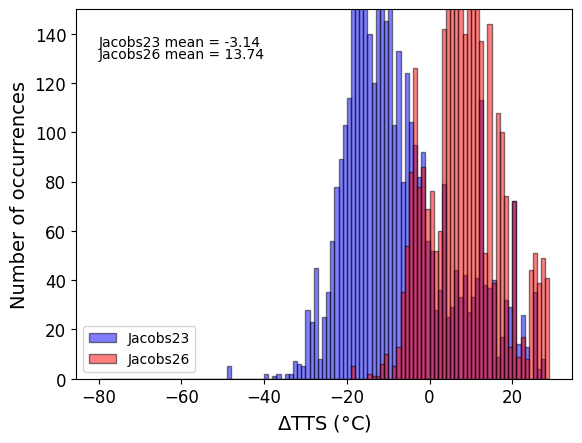

In [ ]:
# Make flux effect crossover histogram

df = DataLoader().load_rpv_data()

model_name_list = ['Jacobs23', 'Jacobs26']
fluence = 6*10**19 # 6*10**19, 1*10**20
plot_flux_effect_crossover_histogram(df,
                                     model_name_list,
                                     fluence=fluence,
                                     flux_plotter=3*10**10,
                                     flux_atr2=3.68*10**12,
                                     anchors='2026',
                                     ymax=150)

Could not find designated model type in scikit-learn model library. Note the other supported modeltype is the keras.wrappers.scikit_learn.KerasRegressor model
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but BaggingRegressor was fitted without feature names
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Could not find designated model type in scikit-learn model library. Note the other supported modeltype is the keras.wrappers.scikit_learn.KerasRegressor model
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but BaggingRegressor was fitted without feature names
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Could not find designated model type in scikit-learn model library. Note the other supported modeltype is the keras.wrappers.scikit_learn.KerasRegressor model
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step

...

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but BaggingRegressor was fitted without feature names
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


Exception ignored in: <function TransformNode.set_children.<locals>.<lambda> at 0x7bcadbfe14e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/matplotlib/transforms.py", line 195, in <lambda>
    self, lambda _, pop=child._parents.pop, k=id_self: pop(k))

KeyboardInterrupt: 


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step

KeyboardInterrupt: 

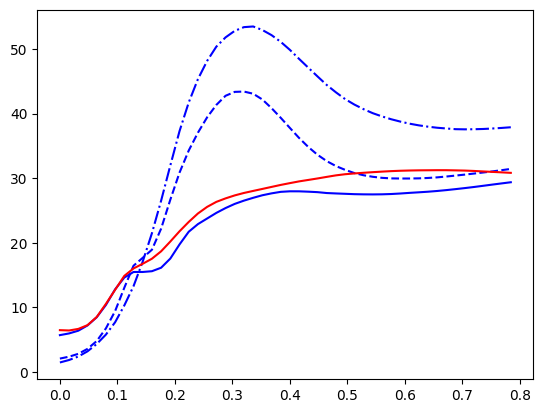

In [ ]:
# Make crossplots

df = DataLoader().load_rpv_data()

plot_crossplot(df,
               #model_name_list=['GKRR'],
               #crossplot_variable_name = 'at_percent_Cu',
               crossplot_variable_name='wt_percent_Cu',
               model_name_list=['Jacobs23', 'Jacobs26'],
               crossplot_variable_min=0,
               crossplot_variable_max=0.8,
               grid_variables = ['wt_percent_Ni'],
               grid_values = [[0.4, 0.8, 1.2]],
               #grid_variables=['log(flux_n_cm2_sec)', 'wt_percent_Ni'],
               #grid_values=[[np.log10(3e10), np.log10(3.68e12)], [0.4, 0.8]],
               num_points=50,
               ymax=250)